# CoCiP Implementation for Comparison to APCEMM

In [1]:
import sys
print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version}")

import pycontrails
print(f"pycontrails version: {pycontrails.__version__}")
print(f"pycontrails location: {pycontrails.__file__}")

Python executable: /home/chinahg/.conda/envs/pycontrails/bin/python
Python version: 3.12.11 | packaged by conda-forge | (main, Jun  4 2025, 14:45:31) [GCC 13.3.0]
pycontrails version: 0.56.0
pycontrails location: /home/chinahg/.conda/envs/pycontrails/lib/python3.12/site-packages/pycontrails/__init__.py


In [2]:
import pycontrails
print(f"pycontrails version: {pycontrails.__version__}")

# Import functions from the pipeline_fxn_lib.py script
import sys
sys.path.append('/home/chinahg/GCresearch/contrailuncertainty/start_here/')
import pipeline_fxn_lib as lib
import run_CoCiP_fxn_lib as cocip_lib

import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

from pycontrails import Flight
from pycontrails.datalib.ecmwf import ERA5
from pycontrails.models.cocip import Cocip
import pycontrails.models.cocip as cocip_module
from pycontrails.models.humidity_scaling import ConstantHumidityScaling
from pycontrails import MetDataset
from pycontrails.models.cocip import contrail_properties as cp

pycontrails version: 0.56.0


# For 6 test cases:
## Setting ice crystal number and initial radius

In [3]:
test_id = "110T205L25"
temperature_test = float(test_id[4:7])  # Extract temperature from test ID
altitude_test = 10700.00  # Altitude in meters for this test
post_vortex_altitude = 10654.12 # Function of aircraft properties and BV stratification level, same for all tests with initial altitude 10700 m
altitude_initial = altitude_test + (altitude_test - post_vortex_altitude)  # Initial altitude before wake vortex effects

csv_path = f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/ice_crystal_number/{test_id}.csv"
df_ice = pd.read_csv(csv_path, header=None)
number_value = df_ice.iat[0, 1]

number_type = "number per meter"  # Type of number being used: "number per meter" for ice particles per meter, "EInvpm" for emissions index
number = float(number_value)
r_ice_string = "1.02e-6" # String version of ice crystal radius for file naming, in micrometers
r_ice = float(r_ice_string)  # m, ice crystal radius for this test
f_surv = 1.0  # Fraction of ice crystals that survive wake vortex sinking for this test

u = 237  # Set true airspeed to 237 m/s
efficiency = 0.3
mdot_f = 1.36986 # Estimated using cruise velocity and fuel flow rate from Lewellen et al. (2014) [kg/s]
epsilon = 0.622 # Ratio of molecular weights of dry air and water vapor
q_fuel = 43e6 # Specific heat of combustion [J/kg]
ei_h2o = 1.24 # emission index of water vapor [kg/kg]
air_pressure = lib.alt2press(altitude_initial) # [Pa]
c_pd = 1005 # Specific heat of dry air
c_pv = 1850 # Specific heat of water vapor
RH = float(test_id[0:3])/100 # Fraction of RHi
q = cocip_lib.estimate_specific_humidity(temperature_test, air_pressure, RH) # Specific humidity
c_pm = c_pd * (1 - q) + c_pv * q # Specific heat capacity of moist air
G = (ei_h2o * c_pm * air_pressure) / (epsilon * q_fuel * (1 - efficiency)) # Slope of SAC
T_LM = cocip_lib.T_sat_liquid(G) # [K]

N = number  # Number of ice crystals per meter

save_dir = f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/{test_id}" # Where the met and rad data will be saved, used for all tests
flight_csv_path = save_dir +f"/{test_id}-flight-cocip-aligned.csv" # Where to save new flight data csv or to read existing data from

make_flight_csv = True  # Set to True to create a new CSV file for the flight. A new CSV is needed if you change the flight properties (ex. EInvpm or wingspan)
save_data = True
check_if_cloudless = False # Whether to check if the ERA5 data is cloudless at the flight points

# For ANOVA testing (dep)

In [4]:
# test_id = "110T218L25"
# temperature_test = float(test_id[4:7])  # Extract temperature from test ID
# altitude_test = 10700.00  # Altitude in meters for this test
# post_vortex_altitude = 10654.12 # Function of aircraft properties and BV stratification level, same for all tests with initial altitude 10700 m
# altitude_initial = altitude_test + (altitude_test - post_vortex_altitude)  # Initial altitude before wake vortex effects

# EInvpm_string = "5e13" # Emissions index being tested
# EInvpm_test = float(EInvpm_string)
# number_type = "nEInvpm"  # Type of number being used: "number per meter" for ice particles per meter, "EInvpm" for emissions index
# number = EInvpm_test
# r_ice_string = "2e-6" # String version of ice crystal radius for file naming, in micrometers
# r_ice = float(r_ice_string)  # m, ice crystal radius for this test
# f_surv = 1.0  # Fraction of ice crystals that survive wake vortex sinking for this test

# u = 237  # Set true airspeed to 237 m/s
# efficiency = 0.3
# mdot_f = 1.36986 # Estimated using cruise velocity and fuel flow rate from Lewellen et al. (2014) [kg/s]
# epsilon = 0.622 # Ratio of molecular weights of dry air and water vapor
# q_fuel = 43e6 # Specific heat of combustion [J/kg]
# ei_h2o = 1.24 # emission index of water vapor [kg/kg]
# air_pressure = lib.alt2press(altitude_initial) # [Pa]
# c_pd = 1005 # Specific heat of dry air
# c_pv = 1850 # Specific heat of water vapor
# RH = float(test_id[0:3])/100 # Fraction of RHi
# q = cocip_lib.estimate_specific_humidity(temperature_test, air_pressure, RH) # Specific humidity
# c_pm = c_pd * (1 - q) + c_pv * q # Specific heat capacity of moist air
# G = (ei_h2o * c_pm * air_pressure) / (epsilon * q_fuel * (1 - efficiency)) # Slope of SAC
# T_LM = cocip_lib.T_sat_liquid(G) # [K]

# activation_rate = cocip_lib.ice_particle_activation_rate(temperature_test, T_LM)
# fuel_per_m = mdot_f / u  # [kg/m]
# N = EInvpm_test * activation_rate * fuel_per_m * f_surv

# save_dir = "micro_sweeps_110_218/" # Where the met and rad data will be saved, used for all tests
# flight_csv_path = f"micro_sweeps_110_218/EInvpm/{EInvpm_string}/{test_id}-flight-cocip-aligned.csv" # Where to save new flight data csv or to read existing data from

# make_flight_csv = False  # Set to True to create a new CSV file for the flight. A new CSV is needed if you change the flight properties (ex. EInvpm or wingspan)
# save_data = False
# check_if_cloudless = False # Whether to check if the ERA5 data is cloudless at the flight points

# Check if radiative data selected is cloudless

In [5]:
check_if_cloudless = True # Whether to check if the ERA5 data is cloudless at the flight points
if check_if_cloudless:
    # check if rad data is cloudless
    ds_met = xr.open_dataset('/home/chinahg/GCresearch/2025_06_29.nc')
    
    # Check if there are any lat/lon pairs with 0 fraction_of_cloud_cover in all levels
    if "cc" not in ds_met:
        print("Dataset does not contain fraction of cloud cover variable 'cc'. Available variables:", list(ds_met.data_vars))
    else:
        cc = ds_met["cc"]
        zero_mask = (cc == 0) & (~xr.ufuncs.isnan(cc))
        zero_all_levels = zero_mask.all(dim="pressure_level")
        time_idx, lat_idx, lon_idx = np.where(zero_all_levels.values)
    
        if len(lon_idx) == 0:
            print("No (longitude, latitude, time) combinations found where fraction_of_cloud_cover is 0 at every level. Please choose a different time or expand the bounds to find cloudless conditions for the flight.")
        else:
            # find coordinates within lat/lon bounds among the zero-all-levels locations
            lat_arr = ds_met["latitude"].values[lat_idx]
            lon_arr = ds_met["longitude"].values[lon_idx]
            time_arr = ds_met["valid_time"].values[time_idx]
    
            bounds_mask = (lat_arr >= 30) & (lat_arr <= 45) & (lon_arr >= -47) & (lon_arr <= -30) & (time_arr >= np.datetime64("2025-06-29T11:00")) & (time_arr <= np.datetime64("2025-06-29T12:00"))
            sel_positions = np.where(bounds_mask)[0]
    
            if sel_positions.size == 0:
                print("No (time, latitude, longitude) combinations in the specified bounds have cc==0 at all levels.")
            else:
            
                df_zero = pd.DataFrame({
                "time": time_arr[sel_positions],
                "latitude": lat_arr[sel_positions],
                "longitude": lon_arr[sel_positions],
                }).drop_duplicates().reset_index(drop=True)
    
                print(f"Found {len(df_zero)} unique (time,lat,lon) combinations in bounds with cc==0 at all levels.")
                display(df_zero.head(100))
    
                # save result for later use
                zero_coords_in_bounds = df_zero

Found 320 unique (time,lat,lon) combinations in bounds with cc==0 at all levels.


,time,latitude,longitude
0,2025-06-29 11:00:00,45.00,-45.75
1,2025-06-29 11:00:00,45.00,-45.50
2,2025-06-29 11:00:00,45.00,-45.25
3,2025-06-29 11:00:00,45.00,-45.00
4,2025-06-29 11:00:00,45.00,-44.75
...,...,...,...
95,2025-06-29 11:00:00,31.50,-33.00
96,2025-06-29 11:00:00,31.25,-38.00
97,2025-06-29 11:00:00,31.25,-37.75
98,2025-06-29 11:00:00,31.00,-38.75


# Set the aircraft and flight parameters to match LES simulations

## Make CSV if needed

In [6]:
# Monkeypatch of iwc_post_wake_vortex function
def my_iwc_post_wake_vortex(iwc, iwc_ad):
    # Calculate the post-vortex iwc such that it follows a specified crystal number per meter and crystal radius
    rho_ice = 917  # kg/m3
    R_dry = 287.05  # J/(kg·K), from CoCiP physics.constants
    p = lib.alt2press(altitude_test) # Pa
    T = temperature_test  # K
    area_eff = 3094.290202803097  # For B767, wingspan = 47.25 m
    rho_air = p / (R_dry * T)
    
    iwc1 = np.ones_like(iwc) * r_ice**3 * 4*np.pi/3 * rho_ice * N * (area_eff * rho_air)**(-1)
    print(f"✓✓✓ CUSTOM iwc_1 = {iwc1[0]}")
    return iwc1

def my_initial_ice_particle_number(aei, fuel_dist, min_aei):
    print(f"✓✓✓ CUSTOM n_per_m_0 CALLED!")
    sys.stdout.flush()
    print(f"    aei shape: {aei.shape}, aei[0] = {aei[0]:.6e}")
    sys.stdout.flush()
    print(f"    fuel_dist shape: {fuel_dist.shape}, fuel_dist[0] = {fuel_dist[0]:.6e}")
    sys.stdout.flush()
    
    initial_num = np.ones_like(aei) * N
    print(f"    Returning n_ice_per_m_0 shape: {initial_num.shape}, [0] = {initial_num[0]:.6e}")
    sys.stdout.flush()
    return initial_num

def my_ice_particle_survival_fraction(iwc, iwc_1):
    f_surv = np.ones_like(iwc)
    print(f"✓✓✓ CUSTOM f_surv = {f_surv[0]}")
    return f_surv


In [7]:
# Monkeypatch the ice_particle_survival_fraction and iwc_post_wake_vortex functions in contrail_properties.py
cp.ice_particle_survival_fraction = my_ice_particle_survival_fraction
cp.iwc_post_wake_vortex = my_iwc_post_wake_vortex
cocip_module.contrail_properties.initial_ice_particle_number = my_initial_ice_particle_number

print(f"Monkeypatch on cocip_module.contrail_properties: {cocip_module.contrail_properties.initial_ice_particle_number}")

if number_type == "number per meter":
    flight_path_csv = f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/{test_id}/{test_id}-flight-cocip-aligned.csv"
elif number_type == "EInvpm":
    flight_path_csv = test_id

if make_flight_csv == True:
    print(f"Initial altitude: {altitude_initial} m Initial temperature: {temperature_test} K Number type: {number_type} Number value: {number}")
    cocip_lib.make_flight_csv(altitude_initial, flight_path_csv, number, flight_csv_path, T_LM, mdot_f, u, efficiency, f_surv, number_type, temperature_test)


Monkeypatch on cocip_module.contrail_properties: <function my_initial_ice_particle_number at 0x7fc472f6e480>
Initial altitude: 10745.88 m Initial temperature: 205.0 K Number type: number per meter Number value: 3580000000000.0
Activation rate: 1.0
Calculated EInvpm to match 3580000000000.0 nvpm/m after vortex sinking: 619377162629757.8 #/kg fuel
Saving new flight CSV to /home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/110T205L25/110T205L25-flight-cocip-aligned.csv


## Load and format the flight data CSV

In [8]:
df_flight, attrs = cocip_lib.format_flight_csv(flight_csv_path)

fl = Flight(data=df_flight, attrs=attrs)

# Check the flight data that will be used
print(f"\nFlight data diagnostics:")
print(f"  fuel_flow[0] = {fl['fuel_flow'][0]}")
print(f"  true_airspeed[0] = {fl['true_airspeed'][0]}")
print(f"  fuel_dist[0] (fuel_flow/true_airspeed) = {fl['fuel_flow'][0] / fl['true_airspeed'][0]}")
print(f"  nvpm_ei_n[0] = {fl.attrs.get('nvpm_ei_n', fl.get('nvpm_ei_n', [None])[0])}")


Flight data diagnostics:
  fuel_flow[0] = 1.36986
  true_airspeed[0] = 237
  fuel_dist[0] (fuel_flow/true_airspeed) = 0.00578
  nvpm_ei_n[0] = 619377162629757.8


# Download radiation data from ERA5

In [11]:
# Get radiative data for clear sky at the nearest lat/lon/time from flight data
# We checked that for time=2025-06-29 00:00 UTC, lat=45.00, lon=-46.50, the fraction_of_cloud_cover is 0 at all levels
time_of_day = "midnight"
time = pd.to_datetime(fl["time"][0]).floor("h")

if f"{test_id}-{time_of_day}-rad.nc" in save_dir:
    print(f"Loading existing rad data from {save_dir}/{test_id}-{time_of_day}-rad.nc")
    xr_era5_rad = xr.open_dataset(f"{save_dir}/{test_id}-{time_of_day}-rad.nc")
else:
    print(f"Downloading new rad data and saving to {save_dir}/{test_id}-{time_of_day}-rad.nc")

    # Download radiation data from ERA5
    era5_single_rad = ERA5(time=time,variables=Cocip.rad_variables).open_metdataset()
    xr_era5_single = era5_single_rad.data

    # Broadcast the clearsky data to have the same time dimension as the flight data
    # Define your desired coordinate grids
    longitudes = np.linspace(-47, -9, int((12+9)/(0.25) + 1))
    latitudes = np.linspace(40, 56, int((56-40)/(0.25) + 1))
    times = pd.date_range(time, periods=40, freq="1H")

    # Select data to broadcast to new xarray dataset
    desired_time = xr_era5_single["time"].values[0]
    desired_latitude = 45.0
    desired_longitude = -46.5

    xr_era5_rad = xr_era5_single.assign(
        {var: xr_era5_single[var].sel(time=desired_time, latitude=desired_latitude, longitude=desired_longitude).broadcast_like(
            xr.DataArray(np.empty((len(times), len(latitudes), len(longitudes))),
                         dims=("time", "latitude", "longitude"),
                         coords={"time": times, "latitude": latitudes, "longitude": longitudes})
        ) for var in xr_era5_single.data_vars}
    )

    # Save the modified rad data to a new NetCDF file
    xr_era5_rad.to_netcdf(f"{save_dir}/{test_id}-{time_of_day}-rad.nc", mode="w", format="NETCDF4")

    # create rad `MetDataset` to feed to CoCiP
    rad = MetDataset(xr_era5_rad)

/tmp/ipykernel_3882630/1110624922.py:20: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  times = pd.date_range(time, periods=40, freq="1H")
/home/chinahg/.local/lib/python3.12/site-packages/dask/array/core.py:4998: PerformanceWarning: Increasing number of chunks by factor of 12
  result = blockwise(
/home/chinahg/.local/lib/python3.12/site-packages/dask/array/core.py:4998: PerformanceWarning: Increasing number of chunks by factor of 12
  result = blockwise(


In [12]:
xr_era5_rad

<xarray.Dataset> Size: 8MB
Dimensions:                    (level: 1, time: 1, latitude: 721,
                                longitude: 1440)
Coordinates:
  * level                      (level) float64 8B -1.0
  * time                       (time) datetime64[ns] 8B 2025-06-29
  * latitude                   (latitude) float64 6kB -90.0 -89.75 ... 90.0
  * longitude                  (longitude) float64 12kB -180.0 -179.8 ... 179.8
    number                     int64 8B ...
    expver                     <U4 16B ...
Data variables:
    top_net_solar_radiation    (time, latitude, longitude, level) float32 4MB dask.array<chunksize=(1, 65, 85, 1), meta=np.ndarray>
    top_net_thermal_radiation  (time, latitude, longitude, level) float32 4MB dask.array<chunksize=(1, 65, 85, 1), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-11-10T21:22 GRIB to CDM+CF via cfgrib-0.9.1...
    pycontrails_version:     0.54.10
    provider:                ECMWF
    dataset:                 ERA5
    product:                 reanalysis

# Create new meteorology to match LES simulations

In [13]:
met_from_scratch = False  # Set to True to create the met dataset from scratch

if met_from_scratch:
    # Make the met file

    # Import APCEMM met data
    xr_apcemm_met = xr.open_dataset(f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/base_inputs/{test_id}/{test_id}.nc")

    # Define dimensions
    longitudes = np.linspace(-180, 179.75, int((180+179.75)/(0.25) + 1))

    latitudes = np.linspace(30, 70, int((70-30)/(0.25) + 1))
    levels = np.flip(xr_apcemm_met['pressure'].values)

    UTC = pd.date_range(start="2025-06-29 00:00:00", periods=60, freq="1h").astype(np.int64) // 10**9
    time = pd.to_datetime(UTC, origin="unix", unit="s") # Convert the UTC time to datetimes and assign to the "time" column

    # Define the additional coordinates to add
    altitudes = np.flip((xr_apcemm_met['altitude'].values).astype(np.float32)) * 1000  # Convert altitude from km to m
    pressures = levels * 100  # Convert pressure from hPa to Pa

    # Define the shpae of the dataset
    new_shape = (len(longitudes), len(latitudes), len(levels), len(time))

    # Create the data to be saved in the new dataset (variables)
    air_temperature = np.broadcast_to(
        np.flip(xr_apcemm_met['temperature'][:,0].values)[np.newaxis, np.newaxis, :, np.newaxis],
        new_shape
    ).astype(np.float32)

    relative_humidity = np.broadcast_to(
        np.flip(xr_apcemm_met['relative_humidity_ice'][:,0].values)[np.newaxis, np.newaxis, :, np.newaxis],
        new_shape
    ).astype(np.float32)

    northward_wind = np.zeros_like(relative_humidity, dtype=np.float32) # Stays 0, only horizontal shearing
    lagrangian_tendency_of_air_pressure = np.zeros_like(relative_humidity, dtype=np.float32) # Stays 0, no downward motion
    specific_cloud_ice_water_content = np.zeros_like(relative_humidity, dtype=np.float32) # Stays 0, no cloud cover

    # Calculate the specific humidity based on RHi and temperature
    T0 = 273.15  # Reference temperature in Kelvin
    T_base = air_temperature[0,0,:,0] # Temperature in Kelvin
    RHi_base = relative_humidity[0,0,:,0]
    pres_base = levels * 100  # Pressure in Pa
    P_sat_w = lib.compute_Psat_w(T_base)
    P_sat_i = lib.compute_Psat_i(T_base)
    q_base = (RHi_base * P_sat_i / P_sat_w) * (1 / (0.263 * pres_base)) * np.exp((17.67 * (T_base - T0)) / (T_base - 29.65))
    specific_humidity = np.broadcast_to(
            q_base[np.newaxis, np.newaxis, :, np.newaxis],  # lon, lat, level, time
            new_shape
        ).astype(np.float32)

    # Calculate the wind feild for constant shear of 0.004 m/s/m
    slope = 0.004  # m/s/m
    u = slope * levels
    eastward_wind = np.broadcast_to(
            u[np.newaxis, np.newaxis, :, np.newaxis],  # lon, lat, level, time
            new_shape
        ).astype(np.float32)

    # Create dataset with the variables and coordinates defined above
    ds_met = xr.Dataset(
        {
            "air_temperature": (['longitude', 'latitude', 'level', 'time'], air_temperature),
            "specific_humidity": (['longitude', 'latitude', 'level', 'time'], specific_humidity),
            "eastward_wind": (['longitude', 'latitude', 'level', 'time'], eastward_wind),
            "northward_wind": (['longitude', 'latitude', 'level', 'time'], northward_wind),
            "lagrangian_tendency_of_air_pressure": (['longitude', 'latitude', 'level', 'time'], lagrangian_tendency_of_air_pressure),
            "specific_cloud_ice_water_content": (['longitude', 'latitude', 'level', 'time'], specific_cloud_ice_water_content),
            "relative_humidity": (['longitude', 'latitude', 'level', 'time'], relative_humidity),

        },
        coords={
            'longitude': longitudes,
            'latitude': latitudes,
            'level': levels,
            'time': time,
            'altitude': ('level', altitudes),
            'air_pressure': ('level', pressures)
        },
        attrs=None
    )

    # Save the modified xr_met to a new NetCDF file
    ds_met.to_netcdf(f"{save_dir}/{test_id}-met.nc", mode="w", format="NETCDF4")

else:
    # Load in the existing met file
    ds_met = xr.open_dataset(f"{save_dir}/{test_id}-met.nc", )

## Plot the meteorological input variables

In [14]:
# Select the first longitude, latitude, and time index
rh_profile = ds_met["relative_humidity"].isel(longitude=0, latitude=0, time=0)
altitudes = ds_met["altitude"].values

# Find indices where altitude is between 11000 and 10000 meters
mask = (altitudes <= 11000) & (altitudes >= 10000)

# Print the altitudes and corresponding relative humidity values
for alt, rh in zip(altitudes[mask], rh_profile.values[mask]):
    print(f"Altitude: {alt:.1f} m, Relative Humidity: {rh:.2f}")

Altitude: 11000.0 m, Relative Humidity: 110.00
Altitude: 10900.0 m, Relative Humidity: 110.00
Altitude: 10800.0 m, Relative Humidity: 110.00
Altitude: 10700.0 m, Relative Humidity: 110.00
Altitude: 10600.0 m, Relative Humidity: 110.00
Altitude: 10500.0 m, Relative Humidity: 110.00
Altitude: 10400.0 m, Relative Humidity: 110.00
Altitude: 10300.0 m, Relative Humidity: 110.00
Altitude: 10200.0 m, Relative Humidity: 110.00
Altitude: 10100.0 m, Relative Humidity: 20.00
Altitude: 10000.0 m, Relative Humidity: 20.00


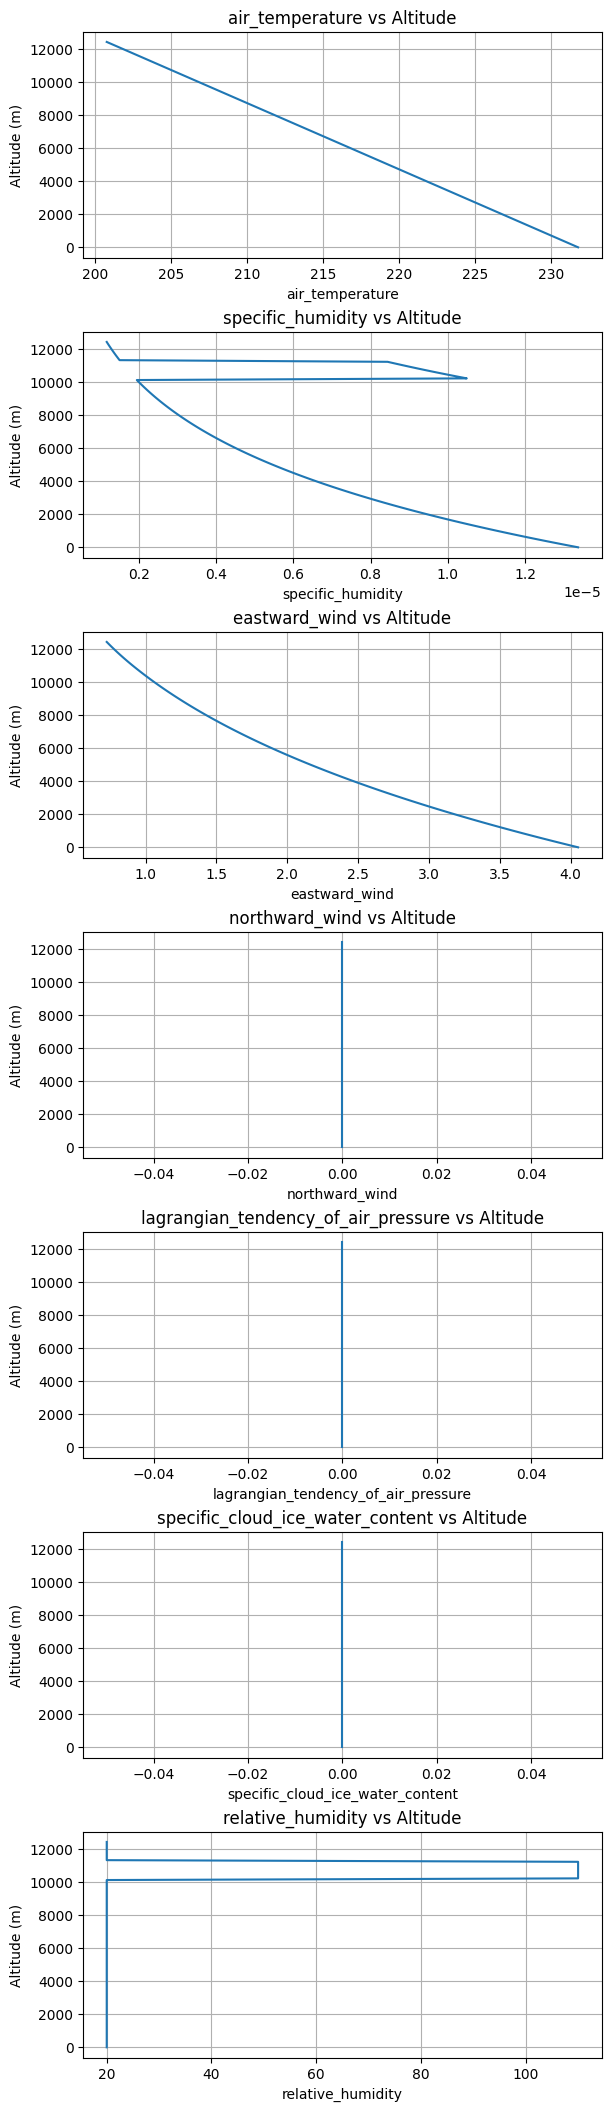

The slope of specific humidity between 10.2-11 km is [-2.0863383e-06 -2.0863383e-06 -2.0863383e-06 -2.0863383e-06
 -2.0863383e-06 -2.0863383e-06 -2.0863383e-06 -2.0863383e-06
 -2.0863383e-06 -2.0863383e-06 -2.0863383e-06 -2.0863383e-06
 -2.0863383e-06 -2.0863383e-06 -2.0863383e-06 -2.0863383e-06
 -2.0863383e-06 -2.0863383e-06 -2.0863383e-06 -2.0863383e-06
 -2.0863383e-06 -2.0863383e-06 -2.0863383e-06 -2.0863383e-06
 -2.0863383e-06 -2.0863383e-06 -2.0863383e-06 -2.0863383e-06
 -2.0863383e-06 -2.0863383e-06 -2.0863383e-06 -2.0863383e-06
 -2.0863383e-06 -2.0863383e-06 -2.0863383e-06 -2.0863383e-06
 -2.0863383e-06 -2.0863383e-06 -2.0863383e-06 -2.0863383e-06
 -2.0863383e-06 -2.0863383e-06 -2.0863383e-06 -2.0863383e-06
 -2.0863383e-06 -2.0863383e-06 -2.0863383e-06 -2.0863383e-06
 -2.0863383e-06 -2.0863383e-06 -2.0863383e-06 -2.0863383e-06
 -2.0863383e-06 -2.0863383e-06 -2.0863383e-06 -2.0863383e-06
 -2.0863383e-06 -2.0863383e-06 -2.0863383e-06 -2.0863383e-06] g/kg/m


In [15]:
# Plot each variable in ds_met as a function of altitude for the first lat, lon, and time indices

fig, axs = plt.subplots(len(ds_met.data_vars), 1, figsize=(6, 3 * len(ds_met.data_vars)), constrained_layout=True)

for i, var in enumerate(ds_met.data_vars):
    # Select the first longitude, latitude, and time index for each variable
    data = ds_met[var].isel(longitude=0, latitude=0, time=0)
    axs[i].plot(data.values, ds_met['altitude'].values)
    axs[i].set_xlabel(var)
    axs[i].set_ylabel('Altitude (m)')
    axs[i].set_title(f"{var} vs Altitude")
    axs[i].grid(True)

plt.show()

mask = (altitudes < 11000) & (altitudes > 10200)
print(f"The slope of specific humidity between 10.2-11 km is {(ds_met['specific_humidity'][0,0,mask,:].values[-1]-ds_met['specific_humidity'][0,0,mask,:].values[0])/(altitudes[mask][-1]-altitudes[mask][0])*1e3} g/kg/m")

## Reformat the met input to work with CoCiP

In [16]:
# Rename the dimensions to match the expected format
new_met = MetDataset(ds_met)

# Run CoCiP

In [17]:
params = {
    "process_emissions": False,
    "verbose_outputs": True,
    "humidity_scaling": ConstantHumidityScaling(rhi_adj=0.98),
    "max_age": np.timedelta64(60, "h"),
    "dt_integration": np.timedelta64(1, "m"),
    "min_ice_particle_number_nvpm_ei_n": 10e10,
}

cocip = Cocip(met=new_met, rad=rad, params=params)

In [18]:
fl_out = cocip.eval(source=fl)

✓✓✓ CUSTOM iwc_1 = 1.170388900778024e-05
✓✓✓ CUSTOM n_per_m_0 CALLED!
    aei shape: (5,), aei[0] = 6.193772e+14
    fuel_dist shape: (5,), fuel_dist[0] = 5.780000e-03
    Returning n_ice_per_m_0 shape: (5,), [0] = 3.580000e+12
✓✓✓ CUSTOM f_surv = 1.0


In [19]:
print(f"\nChecking _sac_flight after eval:")
if hasattr(cocip, '_sac_flight'):
    print(f"  Keys in _sac_flight: {list(cocip._sac_flight.data.keys())}")
    if 'n_ice_per_m_0' in cocip._sac_flight:
        print(f"  n_ice_per_m_0[0] = {cocip._sac_flight['n_ice_per_m_0'][0]:.6e}")
    else:
        print(f"  'n_ice_per_m_0' NOT in _sac_flight!")
        
print(f"\nChecking _downwash_flight after eval:")
if hasattr(cocip, '_downwash_flight'):
    print(f"  Keys in _downwash_flight: {list(cocip._downwash_flight.data.keys())}")
    if 'n_ice_per_m_0' in cocip._downwash_flight:
        print(f"  n_ice_per_m_0[0] = {cocip._downwash_flight['n_ice_per_m_0'][0]:.6e}")
        print(f"  f_surv[0] = {cocip._downwash_flight['f_surv'][0]}")
        print(f"  n_ice_per_m_1[0] = {cocip._downwash_flight['n_ice_per_m_1'][0]:.6e}")
    else:
        print(f"  'n_ice_per_m_0' NOT in _downwash_flight!")


Checking _sac_flight after eval:
  Keys in _sac_flight: ['longitude', 'latitude', 'Altitude (feet)', 'true_airspeed', 'mach_number', 'aircraft_mass', 'fuel_flow', 'engine_efficiency', 'nvpm_ei_n', 'altitude', 'time', 'flight_id', 'level', 'air_pressure', 'waypoint', '_met_intersection', 'air_temperature', 'specific_humidity', 'u_wind', 'v_wind', 'rhi', 'tau_cirrus', 'specific_cloud_ice_water_content', 'rho_air', 'sdr', 'segment_length', 'sin_a', 'cos_a', 'G', 'T_sat_liquid', 'rh', 'rh_critical_sac', 'sac', 'T_critical_sac', 'air_temperature_lower', 'u_wind_lower', 'v_wind_lower', 'dT_dz', 'ds_dz', 'dz_max', 'width', 'depth', 'sigma_yz', 'altitude_1', 'level_1', 'air_temperature_1', 'specific_humidity_1', 'q_sat_1', 'air_pressure_1', 'rho_air_1', 'rhi_1', 'iwc_1', 'f_surv', 'n_ice_per_m_0', 'n_ice_per_m_1', 'persistent_1']
  n_ice_per_m_0[0] = 3.580000e+12

Checking _downwash_flight after eval:
  Keys in _downwash_flight: ['longitude', 'latitude', 'Altitude (feet)', 'true_airspeed', 'm

# Look at available data

In [20]:
fl_out.dataframe.head()

,waypoint,longitude,latitude,Altitude (feet),true_airspeed,mach_number,aircraft_mass,fuel_flow,engine_efficiency,nvpm_ei_n,...,rf_sw_mean,rf_sw_min,rf_sw_max,rf_lw_mean,rf_lw_min,rf_lw_max,rf_net_mean,rf_net_min,rf_net_max,cocip
0,0,-10.070,55.0,36000,237,0.825712,152281.72,1.36986,0.3,6.193772e+14,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,1,-10.273,55.0,36000,237,0.825712,152281.72,1.36986,0.3,6.193772e+14,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,2,-10.476,55.0,36000,237,0.825712,152281.72,1.36986,0.3,6.193772e+14,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,3,-10.680,55.0,36000,237,0.825712,152281.72,1.36986,0.3,6.193772e+14,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,4,-10.883,55.0,36000,237,0.825712,152281.72,1.36986,0.3,6.193772e+14,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [21]:
fl_out.dataframe.columns

Index(['waypoint', 'longitude', 'latitude', 'Altitude (feet)', 'true_airspeed',
       'mach_number', 'aircraft_mass', 'fuel_flow', 'engine_efficiency',
       'nvpm_ei_n', 'altitude', 'time', 'flight_id', 'level', 'air_pressure',
       'air_temperature', 'specific_humidity', 'u_wind', 'v_wind', 'rhi',
       'tau_cirrus', 'specific_cloud_ice_water_content', 'rho_air', 'sdr',
       'segment_length', 'sin_a', 'cos_a', 'G', 'T_sat_liquid', 'rh',
       'rh_critical_sac', 'sac', 'T_critical_sac', 'width', 'depth', 'rhi_1',
       'air_temperature_1', 'specific_humidity_1', 'altitude_1',
       'persistent_1', 'dT_dz', 'ds_dz', 'dz_max', 'rho_air_1', 'iwc_1',
       'f_surv', 'n_ice_per_m_0', 'n_ice_per_m_1', 'ef', 'contrail_age',
       'sdr_mean', 'sdr_min', 'sdr_max', 'rsr_mean', 'rsr_min', 'rsr_max',
       'olr_mean', 'olr_min', 'olr_max', 'rf_sw_mean', 'rf_sw_min',
       'rf_sw_max', 'rf_lw_mean', 'rf_lw_min', 'rf_lw_max', 'rf_net_mean',
       'rf_net_min', 'rf_net_max', 'cocip']

In [22]:
print(f"\nCoCiP internal state after eval:")
print(f"  _sac_flight size: {len(cocip._sac_flight) if hasattr(cocip, '_sac_flight') else 'N/A'}")
print(f"  _downwash_flight size: {len(cocip._downwash_flight) if hasattr(cocip, '_downwash_flight') else 'N/A'}")
print(f"  contrail_list length: {len(cocip.contrail_list) if hasattr(cocip, 'contrail_list') else 'N/A'}")


CoCiP internal state after eval:
  _sac_flight size: 5
  _downwash_flight size: 5
  contrail_list length: 2422


In [23]:
cocip.contrail

,waypoint,flight_id,formation_time,time,age,longitude,latitude,altitude,level,continuous,...,dn_dt_agg,dn_dt_turb,rf_sw,rf_lw,rf_net,persistent,ef,timestep,age_hours,dt_integration
index,,,,,,,,,,,,,,,,,,,,,
0,0,fid,2025-06-29 00:00:00,2025-06-29 00:01:00,0 days 00:00:00,-10.069108,55.0,10702.104193,237.152466,False,...,5.308984e-18,1.581833e-05,0.0,NaN,NaN,True,0.0,0,0.000000,0 days 00:01:00
1,0,fid,2025-06-29 00:00:00,2025-06-29 00:02:00,0 days 00:02:00,-10.068215,55.0,10702.060991,237.154068,True,...,4.729204e-18,1.506492e-05,0.0,NaN,NaN,True,NaN,1,0.033333,0 days 00:01:00
2,1,fid,2025-06-29 00:01:00,2025-06-29 00:02:00,0 days 00:00:00,-10.272108,55.0,10702.104193,237.152466,False,...,5.308984e-18,1.581833e-05,0.0,NaN,NaN,True,0.0,1,0.000000,0 days 00:01:00
3,0,fid,2025-06-29 00:00:00,2025-06-29 00:03:00,0 days 00:03:00,-10.067323,55.0,10702.017608,237.155676,True,...,4.267219e-18,1.439673e-05,0.0,NaN,NaN,True,NaN,2,0.050000,0 days 00:01:00
4,1,fid,2025-06-29 00:01:00,2025-06-29 00:03:00,0 days 00:02:00,-10.271215,55.0,10702.060991,237.154068,True,...,4.729204e-18,1.506492e-05,0.0,NaN,NaN,True,NaN,2,0.033333,0 days 00:01:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12080,3,fid,2025-06-29 00:03:00,2025-06-30 16:19:00,1 days 16:16:00,-8.446051,55.0,10169.211510,257.581906,True,...,7.797175e-22,1.296574e-07,NaN,NaN,NaN,True,NaN,2418,40.266667,0 days 00:01:00
12081,4,fid,2025-06-29 00:04:00,2025-06-30 16:19:00,0 days 00:00:00,-8.650022,55.0,10169.249891,257.580385,False,...,1.417179e-21,1.351132e-07,NaN,NaN,NaN,True,0.0,2418,0.000000,0 days 00:01:00
12082,3,fid,2025-06-29 00:03:00,2025-06-30 16:20:00,1 days 16:17:00,-8.445082,55.0,10169.179689,257.583167,True,...,2.434093e-22,1.220352e-07,NaN,NaN,NaN,True,NaN,2419,40.283333,0 days 00:01:00


In [24]:
waypoint = cocip.contrail[cocip.contrail.waypoint == 0]

In [25]:
waypoint.keys()

Index(['waypoint', 'flight_id', 'formation_time', 'time', 'age', 'longitude',
       'latitude', 'altitude', 'level', 'continuous', 'segment_length',
       'sin_a', 'cos_a', 'width', 'depth', 'sigma_yz', 'air_temperature',
       'specific_humidity', 'air_pressure', 'rhi', 'rho_air', 'q_sat',
       'n_ice_per_m', 'iwc', 'u_wind', 'v_wind', 'vertical_velocity',
       'tau_cirrus', 'air_temperature_lower', 'u_wind_lower', 'v_wind_lower',
       'dT_dz', 'ds_dz', 'dsn_dz', 'sdr', 'top_net_solar_radiation', 'rsr',
       'top_net_thermal_radiation', 'olr', 'area_eff', 'plume_mass_per_m',
       'r_ice_vol', 'terminal_fall_speed', 'diffuse_h', 'diffuse_v',
       'n_ice_per_vol', 'tau_contrail', 'dn_dt_agg', 'dn_dt_turb', 'rf_sw',
       'rf_lw', 'rf_net', 'persistent', 'ef', 'timestep', 'age_hours',
       'dt_integration'],
      dtype='object')

In [26]:
# Convert the waypoint DataFrame to a DataSet
waypoint_ds = waypoint.to_xarray()

In [27]:
if save_data == True:
    # Save the waypoint DataFrame to a .nc file
    waypoint_ds.to_netcdf(f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/{test_id}/{test_id}-bypass.nc")
    print(f"Data saved successfully to /home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/{test_id}/{test_id}-bypass.nc.")
else:
    print("Data not saved. Set save_data = True to save the data.")

Data saved successfully to /home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/110T205L25/110T205L25-bypass.nc.


In [28]:
# waypoint_ds.to_netcdf(f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/micro_sweeps_110_218/EInvpm/{EInvpm_string}/IND_{EInvpm_string}_{r_ice_string}.nc")

# # compare datasets from batch vs individual cocip runs
# cocip_ind = xr.open_dataset(f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/micro_sweeps_110_218/EInvpm/5e13/IND_5e13_2e-6.nc", decode_cf=False)
# cocip_batch = xr.open_dataset("/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/micro_sweeps_110_218/EInvpm/5e13/5e13_2e-6.nc", decode_cf=False)

# cocip_batch.identical(cocip_ind)

# Plot key variables for a single waypoint

First reported contrail age:  0.0


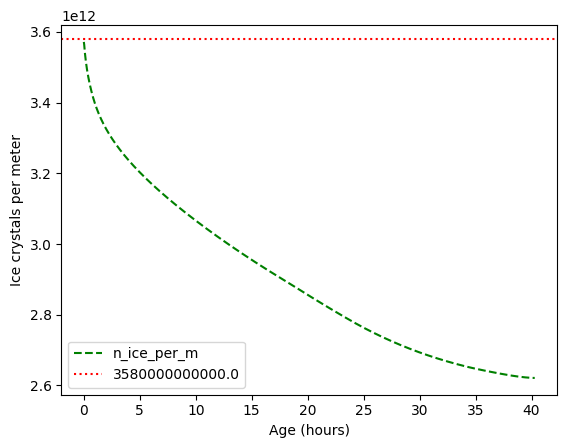

In [29]:
ax = plt.axes()
waypoint.plot(
    "age_hours",
    "n_ice_per_m",
    ax=ax,
    xlabel="Age (hours)",
    ylabel="Ice crystals per meter",
    color="green",
    legend=False,
    linestyle='--',
)
ax.axhline(N, color='red', linestyle=':', label=str(N))
ax.legend()
print("First reported contrail age: ", waypoint.age_hours.values[0])

In [30]:
print(f"The first value of Ice Crystals per m vs the expected value of {N} is {waypoint["n_ice_per_m"][0]}")

The first value of Ice Crystals per m vs the expected value of 3580000000000.0 is 3571771852540.7104


np.float64(1213583905.3384411)

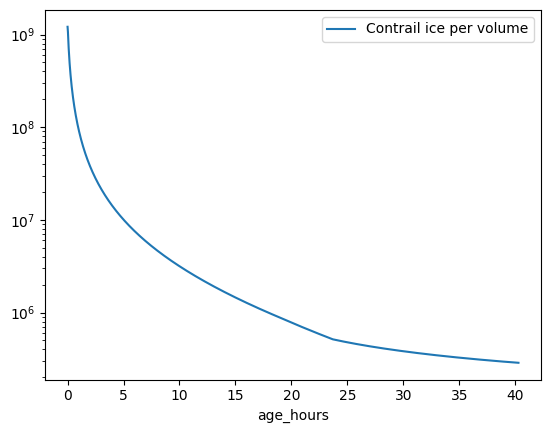

In [31]:
ax = plt.axes()
waypoint.plot(
    "age_hours",
    "n_ice_per_vol",
    ax=ax,
    label="Contrail ice per volume"
)
ax.set_yscale("log")

waypoint["n_ice_per_vol"].iloc[0]

<Axes: xlabel='age_hours'>

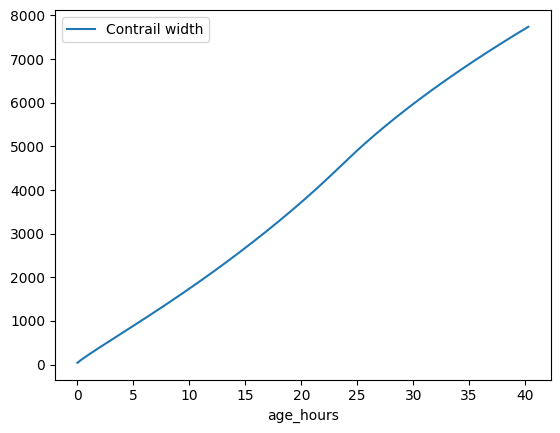

In [32]:
ax = plt.axes()
waypoint.plot(
    "age_hours",
    "width",

    ax=ax,
    label="Contrail width"
)

<Axes: xlabel='age_hours'>

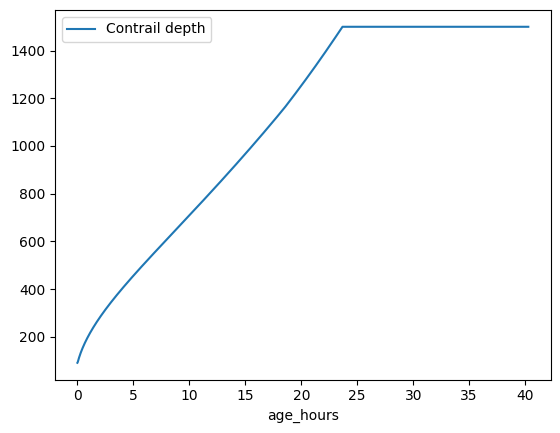

In [33]:
ax = plt.axes()
waypoint.plot(
    "age_hours",
    "depth",

    ax=ax,
    label="Contrail depth"
)

First reported contrail altitude:  10702.104193280846


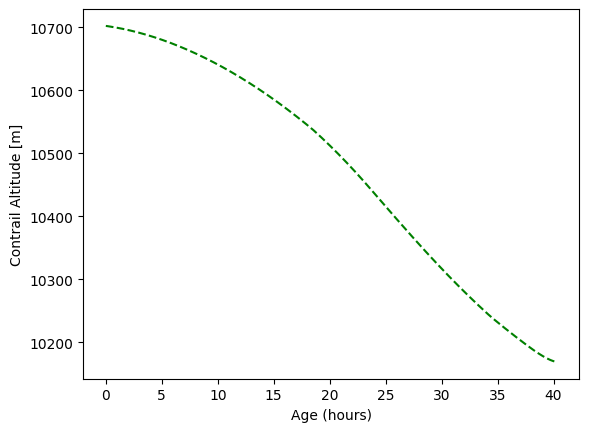

In [34]:
ax = plt.axes()
waypoint.plot(
    "age_hours",
    "altitude",

    ax=ax,

    xlabel="Age (hours)",
    ylabel="Contrail Altitude [m]",
    color="green",
    linestyle='--',
    legend=False
)
print("First reported contrail altitude: ", waypoint.altitude.values[0])

<Axes: xlabel='age_hours'>

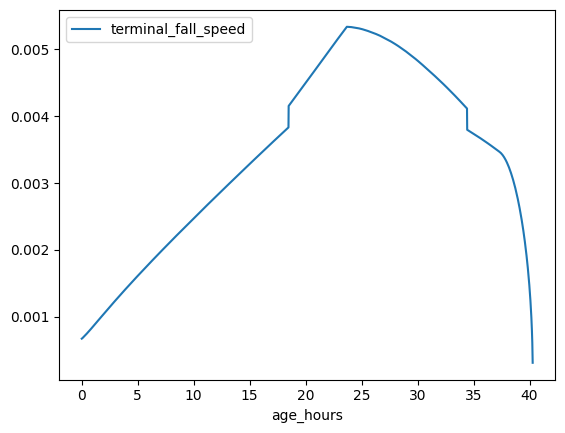

In [35]:
ax = plt.axes()
waypoint.plot(
    "age_hours",
    "terminal_fall_speed",

    ax=ax,
    label="terminal_fall_speed"
)

<Axes: xlabel='age_hours'>

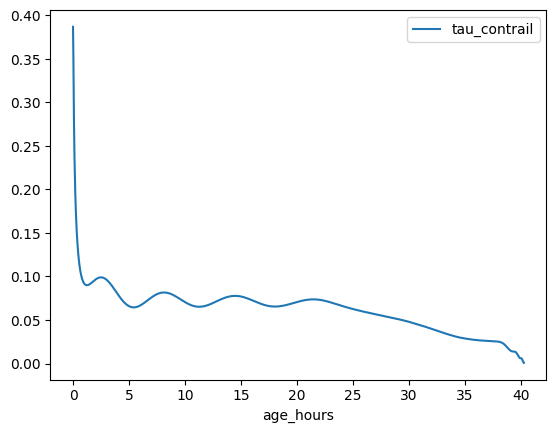

In [36]:
ax = plt.axes()
waypoint.plot(
    "age_hours",
    "tau_contrail",

    ax=ax,
    label="tau_contrail"
)

<Axes: xlabel='Age (hours)', ylabel='Ice crystal radius (microns)'>

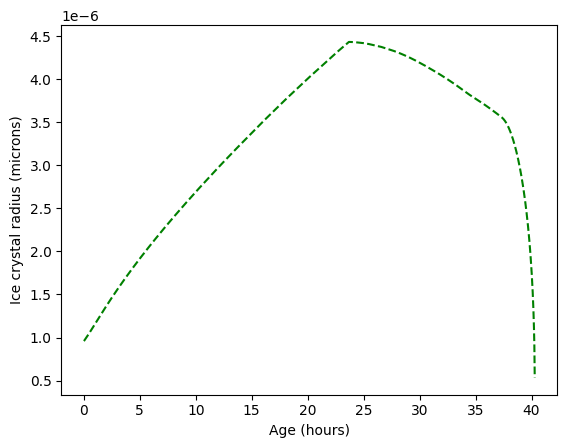

In [37]:
ax = plt.axes()
waypoint.plot(
    "age_hours",
    "r_ice_vol",

    ax=ax,

    xlabel="Age (hours)",
    ylabel="Ice crystal radius (microns)",
    color="green",
    legend=False,
    linestyle='--',
)

In [38]:
ds_met.close()